# PLIP Retrieval and Evaluation with Matches Dataset

In this notebook, we will:

- Load the saved embeddings and data from both the PubMed dataset and the matches dataset.
- Build separate FAISS indices for efficient retrieval.
- Use an image from the matches dataset as a query image.
- Retrieve similar images from both datasets.
- Compare the retrieved results to the known matching images.
- Evaluate the retrieval performance.
- Clear memory after processing.

---

## **Step 1: Import Libraries**

We begin by importing the necessary libraries.

In [1]:
# Import necessary libraries
import os
import numpy as np
import torch
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import random
import re
import gc

---

## **Step 2: Set Up Device**

We set up the device to use GPU if available, otherwise CPU.

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---

## **Step 3: Define Helper Functions**

We define functions for image preprocessing and retrieval.

In [3]:
# Function to preprocess images
def preprocess_image(image_path, size=(224, 224), contrast_factor=1.5):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(size)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(contrast_factor)
    return img

# Function to retrieve top K similar images by processing embeddings in chunks
def retrieve_top_k_in_chunks(query_embedding, embeddings_path, k=5, chunk_size=10000):
    num_embeddings = len(paths_pubmed)
    top_k_distances = []
    top_k_indices = []

    for start_idx in range(0, num_embeddings, chunk_size):
        end_idx = min(start_idx + chunk_size, num_embeddings)
        embeddings_chunk = np.load(embeddings_path, mmap_mode='r')[start_idx:end_idx]
        embeddings_chunk = embeddings_chunk.astype('float32')

        # Compute cosine similarities (dot product since embeddings are normalized)
        similarities = np.dot(embeddings_chunk, query_embedding.flatten())

        # Get top K indices within the chunk
        chunk_top_k_indices = similarities.argsort()[-k:][::-1]
        chunk_top_k_similarities = similarities[chunk_top_k_indices]

        # Adjust indices
        chunk_top_k_indices = chunk_top_k_indices + start_idx

        # Collect results
        top_k_distances.extend(chunk_top_k_similarities)
        top_k_indices.extend(chunk_top_k_indices)

        # Clean up
        del embeddings_chunk
        similarities = None
        gc.collect()

    # Convert to NumPy arrays
    top_k_distances = np.array(top_k_distances)
    top_k_indices = np.array(top_k_indices)

    # Get overall top K
    sorted_indices = np.argsort(-top_k_distances)[:k]
    final_distances = top_k_distances[sorted_indices]
    final_indices = top_k_indices[sorted_indices]

    return final_distances, final_indices

---

## **Step 4: Load Embeddings and Data**

In [4]:
# Load PubMed data
embeddings_path_pubmed = 'embeddings_pubmed.npy'
paths_pubmed = np.load('paths_pubmed.npy', allow_pickle=True)
captions_pubmed = np.load('captions_pubmed.npy', allow_pickle=True)

# Load Matches data
embeddings_matches = np.load('embeddings_matches.npy')
paths_matches = np.load('paths_matches.npy', allow_pickle=True)
captions_matches = np.load('captions_matches.npy', allow_pickle=True)

---

## **Step 5: Load Embeddings and Data**

We load the embeddings and related data saved from the previous notebook.

In [5]:
# Load the query embedding
query_embedding_np = np.load('query_embedding.npy')

# Load query image info
query_image_info = np.load('query_image_info.npy', allow_pickle=True)
query_image_filename = query_image_info[0]
query_image_path = query_image_info[1]

# Load other matching images
other_matching_images = np.load('other_matching_images.npy', allow_pickle=True)

print(f"Loaded query image: {query_image_filename}")
print(f"Other matching images: {other_matching_images}")

Loaded query image: 722_04.jpg
Other matching images: ['722_01.jpg' '722_03.jpg']


---

## **Step 6: Perform Retrieval from PubMed Dataset in Chunks**

In [6]:
# Set k (number of results)
k = 5

# Retrieve from PubMed embeddings in chunks
distances_pubmed, indices_pubmed = retrieve_top_k_in_chunks(query_embedding_np, embeddings_path_pubmed, k=k, chunk_size=10000)

---

## **Step 7: Perform Retrieval from Matches Dataset**

In [7]:
# Since matches dataset is small, we can process it entirely

# Normalize query embedding if not already normalized
# query_embedding_np = query_embedding_np / np.linalg.norm(query_embedding_np)

# Compute similarities with matches embeddings
similarities_matches = np.dot(embeddings_matches, query_embedding_np.flatten())

# Get top K indices
indices_matches = similarities_matches.argsort()[-k:][::-1]
distances_matches = similarities_matches[indices_matches]

# Adjust indices for matches dataset
indices_matches_adjusted = indices_matches + len(paths_pubmed)

---

## **Step 8: Combine and Sort Results**

In [8]:
# Combine distances and indices
combined_distances = np.concatenate((distances_pubmed, distances_matches))
combined_indices = np.concatenate((indices_pubmed, indices_matches_adjusted))

# Combine paths and captions
combined_paths = np.concatenate((paths_pubmed, paths_matches))
combined_captions = np.concatenate((captions_pubmed, captions_matches))

# Get overall top K
sorted_indices = np.argsort(-combined_distances)[:k]
top_k_distances = combined_distances[sorted_indices]
top_k_indices = combined_indices[sorted_indices]

---

## **Step 9: Display Query Image**

Query Image:


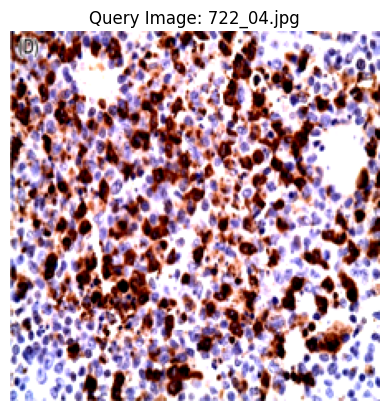

In [9]:
# Display query image
print("Query Image:")
query_image = preprocess_image(query_image_path)
plt.imshow(query_image)
plt.title(f"Query Image: {query_image_filename}")
plt.axis('off')
plt.show()
plt.close()
query_image.close()

---

## **Step 10: Display Retrieved Images**

Top 5 similar images:


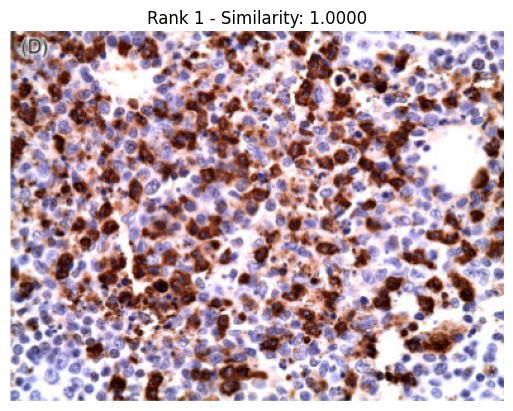

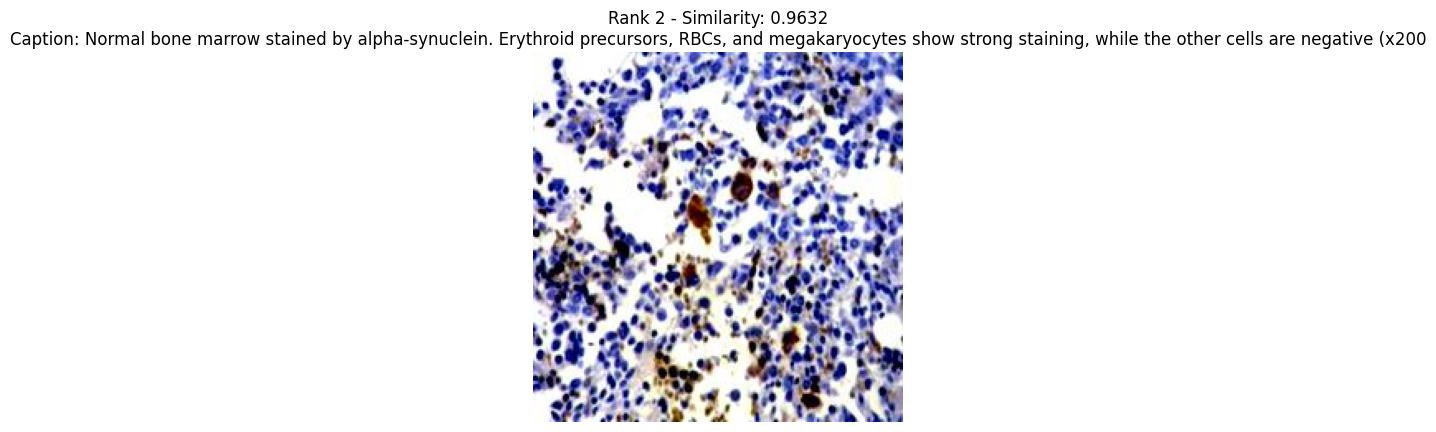

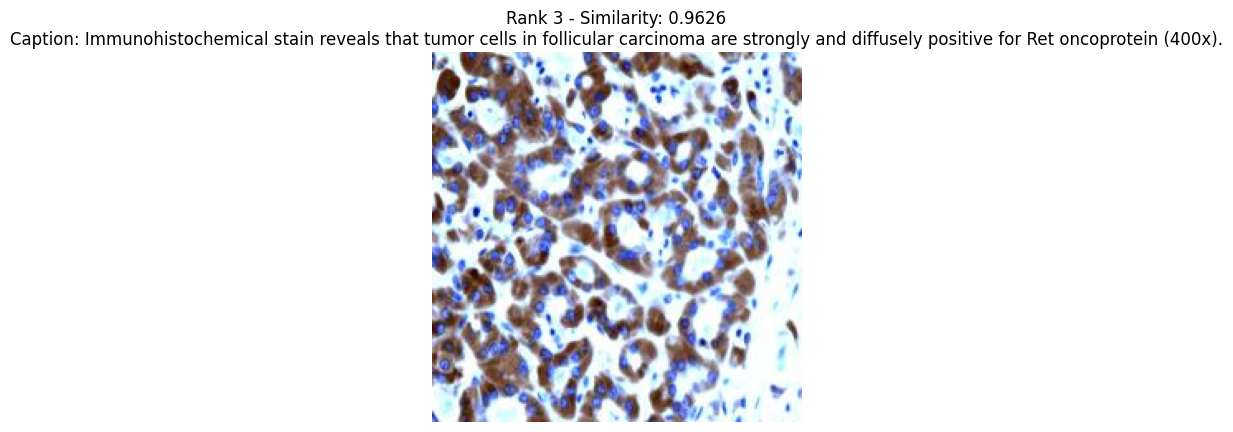

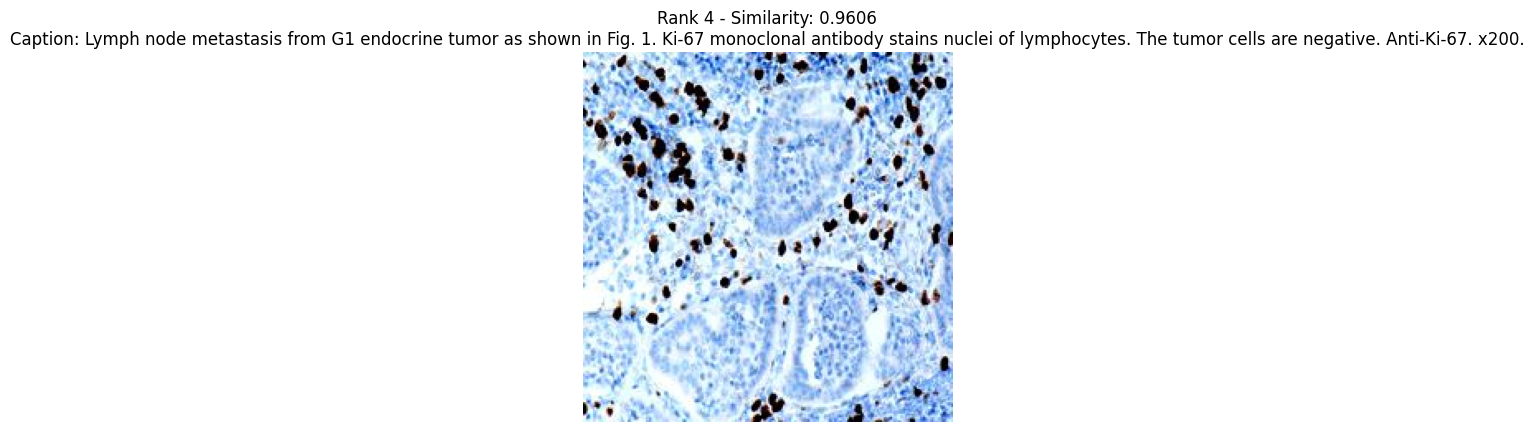

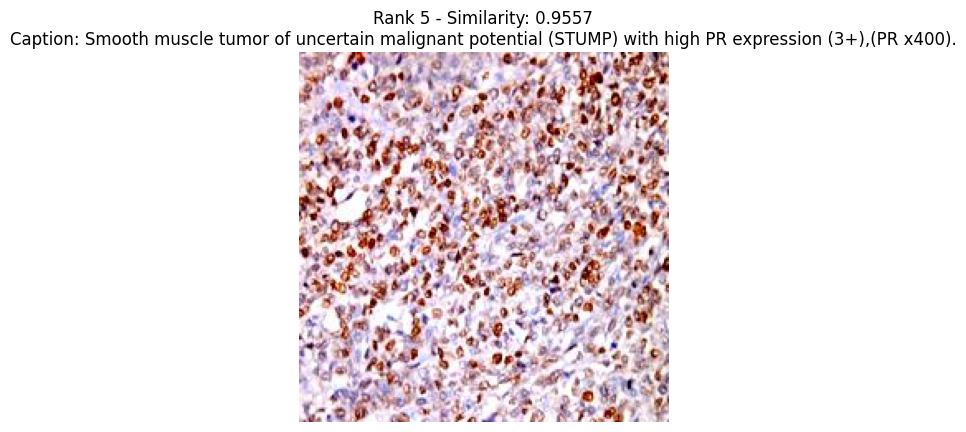

In [10]:
# Display retrieved images
print(f"Top {k} similar images:")
for rank, idx in enumerate(top_k_indices):
    retrieved_image_path = combined_paths[idx]
    retrieved_caption = combined_captions[idx]
    similarity = top_k_distances[rank]
    
    # Display image
    retrieved_image = Image.open(retrieved_image_path)
    plt.imshow(retrieved_image)
    title_text = f"Rank {rank + 1} - Similarity: {similarity:.4f}"
    if retrieved_caption:
        title_text += f"\nCaption: {retrieved_caption}"
    plt.title(title_text)
    plt.axis('off')
    plt.show()
    plt.close()
    retrieved_image.close()

---

## **Step 11: Display Known Matching Images**

Known Matching Images:


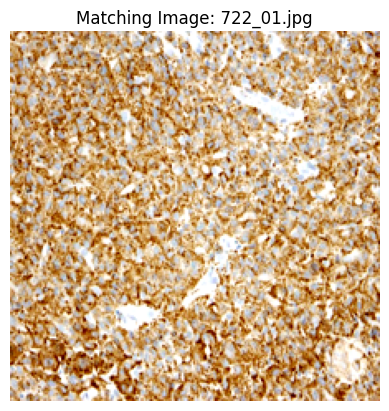

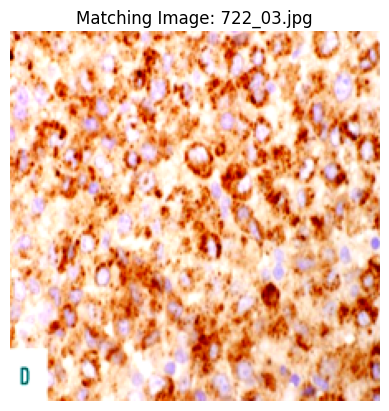

In [11]:
# Display known matching images
print("Known Matching Images:")
for img_filename in other_matching_images:
    img_path = os.path.join('./matches/', img_filename)
    img = preprocess_image(img_path)
    plt.imshow(img)
    plt.title(f"Matching Image: {img_filename}")
    plt.axis('off')
    plt.show()
    plt.close()
    img.close()

---

## **Step 12: Evaluate Retrieval Performance**

In [12]:
# Check if any of the retrieved images are from the matching set
retrieved_filenames = [os.path.basename(combined_paths[idx]) for idx in top_k_indices]
matches_found = set(retrieved_filenames) & set(other_matching_images)

print(f"Retrieved images from matching set: {matches_found}")

# Calculate Precision@K
precision = len(matches_found) / k
print(f"Precision@{k}: {precision:.2f}")

Retrieved images from matching set: set()
Precision@5: 0.00


---

## **Step 13: Clean Up**

In [13]:
# Clear memory
del embeddings_matches, paths_matches, captions_matches
del embeddings_path_pubmed, paths_pubmed, captions_pubmed
import gc
gc.collect()

10142

---

## **Step 14: Conclusion**

We have:

- Used an image from the matches dataset as the query image.
- Retrieved similar images from both the PubMed dataset and the matches dataset.
- Displayed the retrieved images and the known matching images.
- Evaluated the retrieval performance.

**Next Steps:**

- Fine-tune the PLIP model on the matches dataset to improve retrieval performance.
- Experiment with different values of K and evaluate metrics like Recall@K and Mean Average Precision (mAP).